In [5]:
!pip install yfinance

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
# Get Apple stock data
df = yf.download("AAPL", start="2025-01-01", end="2026-04-28")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.301926,247.518596,240.284814,247.349662,55740700
2025-01-03,241.815033,242.629819,240.354364,241.815033,40244100
2025-01-06,243.444641,245.759851,241.656065,242.759019,45045600
2025-01-07,240.672333,243.991125,239.817792,241.437433,40856000
2025-01-08,241.159210,242.162808,238.526040,240.384163,37628900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 329 entries, 2025-01-02 to 2026-04-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   329 non-null    float64
 1   (High, AAPL)    329 non-null    float64
 2   (Low, AAPL)     329 non-null    float64
 3   (Open, AAPL)    329 non-null    float64
 4   (Volume, AAPL)  329 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 15.4 KB


In [3]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [4]:
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [5]:
features = [(  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')]

In [6]:
df['Target'] = df[('Close','AAPL')].shift(-1)
df.dropna(inplace=True)
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
Target            0
dtype: int64

In [7]:
X = df[features]
y = df['Target']

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30, shuffle =False)

In [24]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred = regression.predict(X_test)

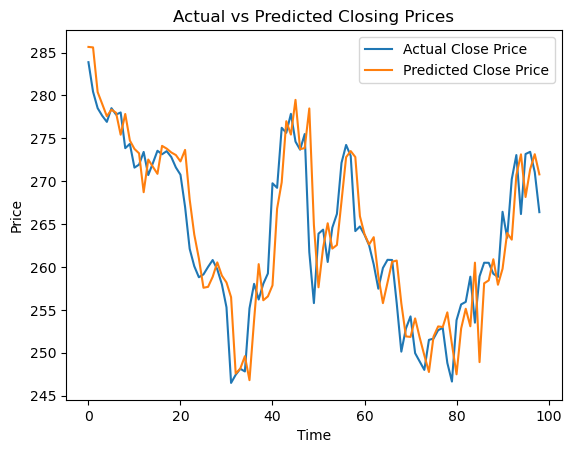

In [26]:
import matplotlib.pyplot as plt

plt.plot(y_test.values, label='Actual Close Price')
plt.plot(y_pred, label='Predicted Close Price')

plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error,r2_score
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("R2_score : ",r2_score(y_test,y_pred))

MAE :  3.195637533713792
R2_score :  0.7891503158204888


In [28]:
from sklearn.metrics import mean_squared_error

train_pred = regression.predict(X_train)

train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, y_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 21.344142053256235
Test MSE: 18.66932850463098
